# Kaggle NYC Taxi Fare - 데이터 전처리와 EDA (재현용 노트북)

> ⚠️ **안내**: 이 실습은 원래 강의 플랫폼 내에서 진행하여 별도의 노트북이 없었다.
> 이 노트북은 블로그 정리를 위해 **Kaggle "New York City Taxi Fare Prediction"과 동일한 컬럼 구조의 재현용 샘플 데이터**로
> 동일한 전처리/EDA 파이프라인을 다시 실행한 것이다. 코드 로직은 실습과 동일하며, 결과 수치는 샘플 데이터 기준이다.

**진행 순서**: 데이터 로드 → 결측치 처리 → 이상치 제거 → 상관관계 분석 → 거리 Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 데이터 불러오기

CSV 파일을 DataFrame으로 불러온다.

In [ ]:
def load_csv(path):
    data_frame = pd.read_csv(path)
    return data_frame

DATA_PATH = "taxi_sample.csv"   # 재현용 샘플 (원본은 Kaggle train.csv)
df = load_csv(DATA_PATH)

print("--- Data Shape ---")
print(df.shape)
print("\n--- Head ---")
print(df.head().to_string())

--- Data Shape ---
(5000, 9)

--- Head ---
   Unnamed: 0         id  fare_amount      pickup_datetime  pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count
0           0  id0000000         5.80  2015-01-01 00:00:00         -73.97086         40.74226          -73.96733          40.76083              3.0
1           1  id0000001        13.50  2015-01-01 00:01:00         -74.01120         40.74102          -73.99322          40.76024              3.0
2           2  id0000002        13.95  2015-01-01 00:02:00         -73.95749         40.72910          -73.98693          40.74410              2.0
3           3  id0000003         4.97  2015-01-01 00:03:00         -73.95178         40.76285          -73.95749          40.77166              2.0
4           4  id0000004         8.48  2015-01-01 00:04:00         -74.03853         40.75704          -74.02195          40.76530              4.0


## 2. 결측치 확인

`isnull().sum()`으로 컬럼별 결측치 개수를 확인한다.

In [ ]:
print("--- 결측치 개수 ---")
print(df.isnull().sum())

--- 결측치 개수 ---
Unnamed: 0            0
id                    0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    60
dropoff_latitude      0
passenger_count      59
dtype: int64


## 3. 결측치 처리

불필요한 컬럼(`Unnamed: 0`, `id`)을 제거하고, 결측치가 포함된 행을 `dropna()`로 삭제한다.

- `Unnamed: 0`: CSV 저장 과정에서 생긴 인덱스 → 학습에 의미 없음
- `id`: 데이터 식별자일 뿐 요금 예측에 도움 안 됨

In [ ]:
def del_missing(df):
    del_un_df = df.drop(['Unnamed: 0'], axis='columns')
    del_un_id_df = del_un_df.drop(['id'], axis='columns')
    removed_df = del_un_id_df.dropna()
    return removed_df

before = df.shape
df = del_missing(df)
print(f"결측치 처리 전: {before}")
print(f"결측치 처리 후: {df.shape}")
print(f"남은 결측치: {df.isnull().sum().sum()}")

결측치 처리 전: (5000, 9)
결측치 처리 후: (4881, 7)
남은 결측치: 0


## 4. 이상치(Outlier) 제거

세 가지 비정상 데이터를 제거한다.

- ① 음수 요금 (`fare_amount < 0`) → 요금은 음수가 될 수 없음
- ② 음수 승객 수 (`passenger_count < 0`) → 승객 수는 음수가 될 수 없음
- ③ 출발 위치 == 도착 위치 → 이동 거리 0, 일반 운행과 다른 특성

In [ ]:
before = len(df)

# ① 음수 요금 제거
df = df[df['fare_amount'] >= 0]
# ② 음수 승객 수 제거
df = df[df['passenger_count'] >= 0]
# ③ 출발 == 도착 위치 제거
same_mask = (df['pickup_longitude'] == df['dropoff_longitude']) & \
            (df['pickup_latitude'] == df['dropoff_latitude'])
df = df[~same_mask]

print(f"이상치 제거 전 행 수: {before}")
print(f"이상치 제거 후 행 수: {len(df)}")
print(f"제거된 행 수: {before - len(df)}")

이상치 제거 전 행 수: 4881
이상치 제거 후 행 수: 4781
제거된 행 수: 100


## 5. 상관관계 분석 (raw 특성)

`df.corr()`로 상관계수를 계산하고 Heatmap으로 시각화한다.
(`numeric_only=True`로 datetime 같은 비수치 컬럼은 자동 제외)

--- fare_amount 상관계수 (raw 좌표) ---
fare_amount          1.000000
dropoff_longitude    0.032158
pickup_longitude     0.026080
passenger_count      0.025868
dropoff_latitude     0.020252
pickup_latitude     -0.003038
Name: fare_amount, dtype: float64


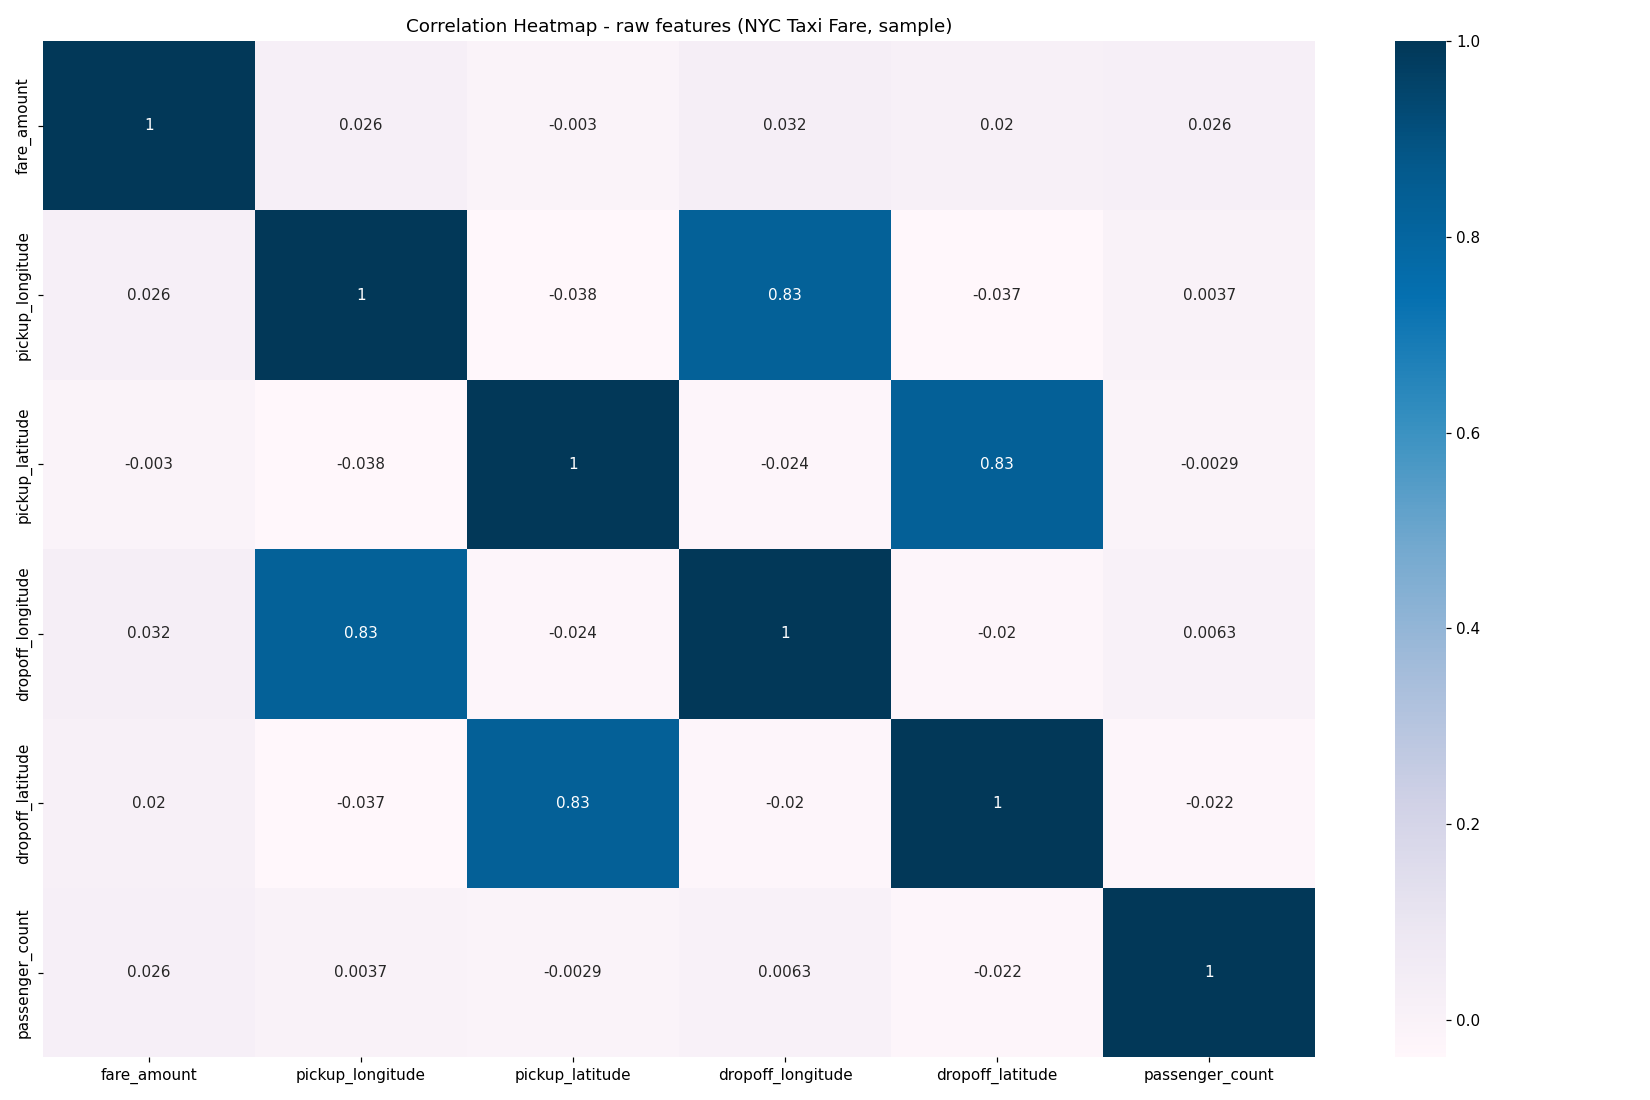

In [ ]:
corr_df = df.corr(numeric_only=True)
print("--- fare_amount 상관계수 (raw 좌표) ---")
print(corr_df['fare_amount'].sort_values(ascending=False))

plt.figure(figsize=(15, 10))
sns.heatmap(corr_df, annot=True, cmap="PuBu")
plt.title("Correlation Heatmap - raw features")
plt.show()

### 🔎 여기서 발견한 것

raw 좌표(pickup/dropoff longitude·latitude)는 `fare_amount`와 상관계수가 거의 **0**에 가깝다.

즉, "위도·경도 값 자체"는 요금과 직접적인 관계가 없다.
당연한 결과인데, 요금은 특정 좌표가 아니라 **출발지에서 도착지까지의 이동 거리**에 비례하기 때문이다.

→ 그래서 다음 단계로 **거리(distance) Feature를 직접 만들어주는 Feature Engineering**이 필요하다.

## 6. Feature Engineering - 이동 거리 만들기

출발/도착 좌표로부터 실제 이동 거리(km)를 계산하는 `distance_km` 컬럼을 만든다.
위경도 간 거리는 **Haversine 공식**으로 구한다.

--- fare_amount 상관계수 (distance_km 추가 후) ---
fare_amount          1.000000
distance_km          0.898807
dropoff_longitude    0.032158
pickup_longitude     0.026080
passenger_count      0.025868
dropoff_latitude     0.020252
pickup_latitude     -0.003038
Name: fare_amount, dtype: float64


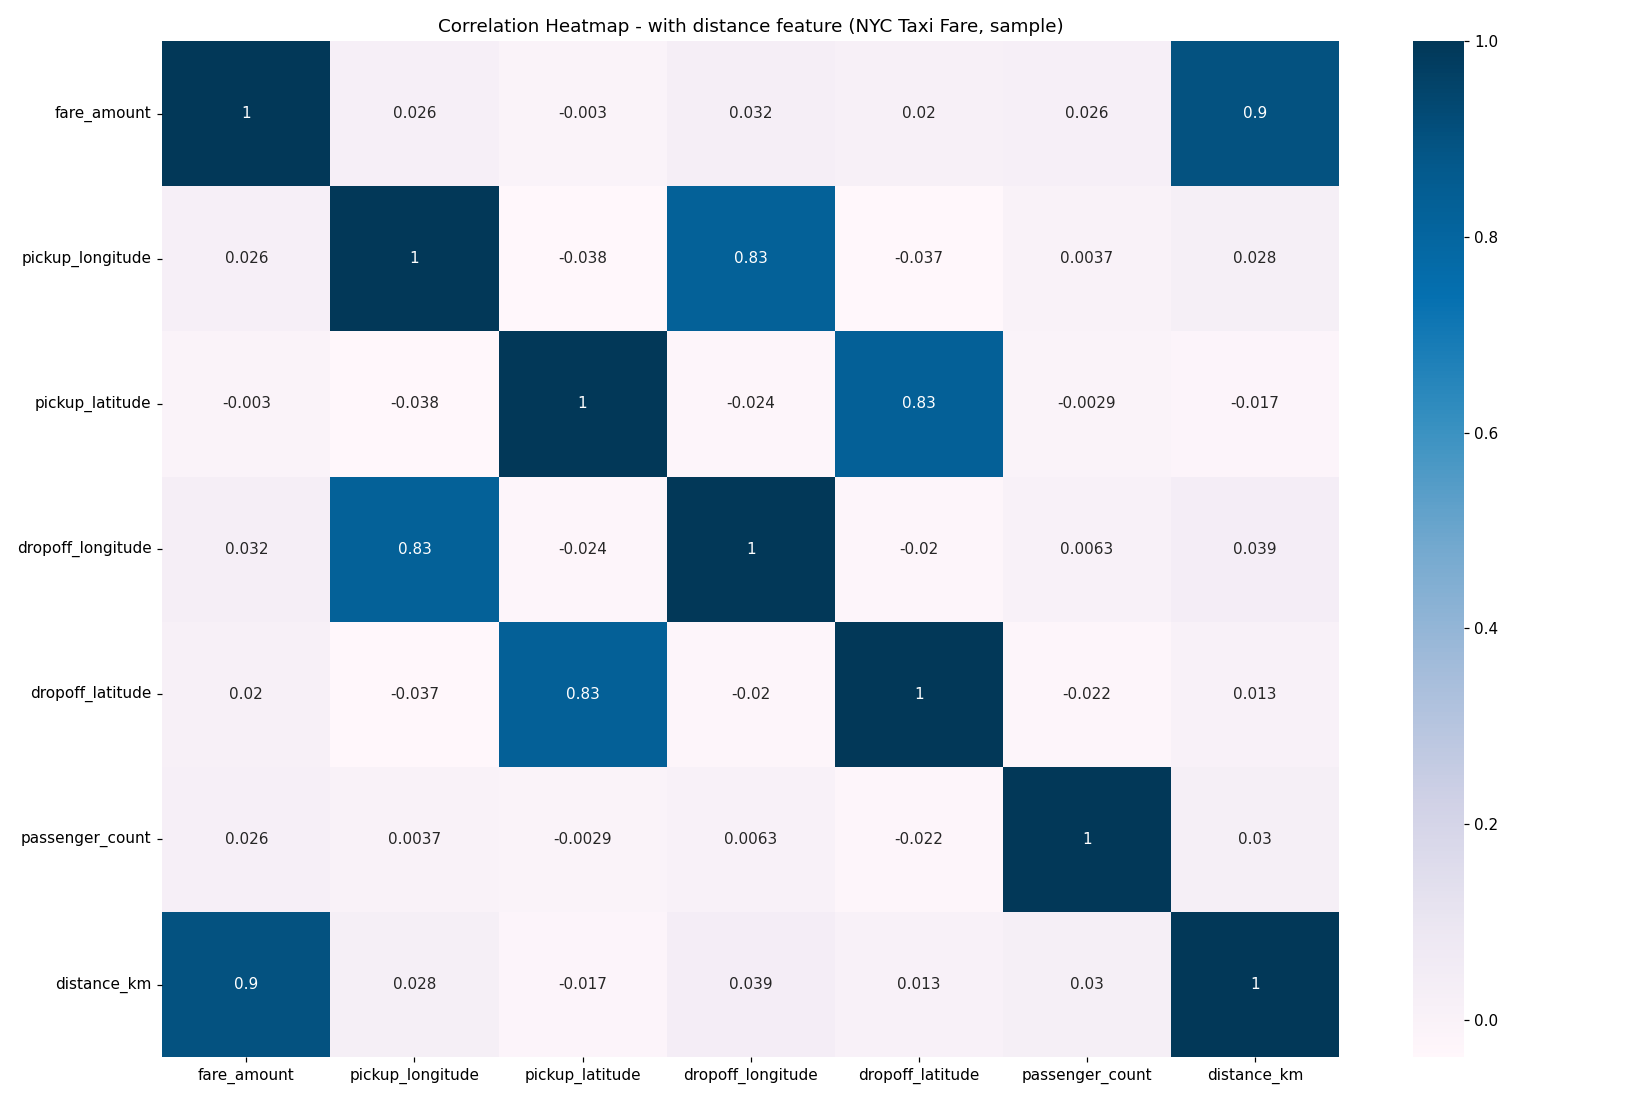

In [ ]:
def haversine(lon1, lat1, lon2, lat2):
    # 위경도 -> km 단위 거리
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['pickup_longitude'], df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

corr_df = df.corr(numeric_only=True)
print("--- fare_amount 상관계수 (distance_km 추가 후) ---")
print(corr_df['fare_amount'].sort_values(ascending=False))

plt.figure(figsize=(15, 10))
sns.heatmap(corr_df, annot=True, cmap="PuBu")
plt.title("Correlation Heatmap - with distance feature")
plt.show()

### ✅ 결과

새로 만든 `distance_km`은 `fare_amount`와 상관계수 **약 0.9**로 매우 강한 관계를 보인다.

raw 좌표(~0)와 비교하면, 같은 데이터라도 **어떤 Feature로 가공하느냐**에 따라
모델이 학습할 수 있는 신호의 질이 완전히 달라진다는 것을 확인할 수 있다.

이것이 EDA와 Feature Engineering을 함께 하는 이유다.